In [1]:
from topological_insulator import Problem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

In [ ]:
import numpy as np

def set_eigenvalues(problem:Problem, Delta_SOC, t_1, delta):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for label_i in subs:
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                # parser["nn_hopping"][label_j]["t_ss_sigma"] = 0.2 * t_1
                # parser["nn_hopping"][label_j]["t_sp_sigma"] = 1
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t_1 - delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = t_1 + delta
            except:
                pass
        # print(parser)   

In [4]:
location = "bulk"

In [5]:
Delta_SOC = -5
cases = {
    0: {"t_1": -1, "delta": 0}, # 0.632 doesn't open gap
    1: {"t_1": -1, "delta": 0.732},
    2: {"t_1": -1, "delta": 0.832},
    3: {"t_1": -1, "delta": 1},
    4: {"t_1": -1, "delta": 1.32},
}

In [6]:
results = {}
for n, eigenvalue_dict in cases.items():
    t_1 = eigenvalue_dict["t_1"]
    delta = eigenvalue_dict["delta"]
    print("")
    print(f"Running case for: delta/t_1 = {delta/t_1}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    set_eigenvalues(problem, Delta_SOC, t_1, delta)
    problem.setup(
        N_r = 10,
        N_k = 250,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: delta/t_1 = -0.0
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t_1 = -0.732
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t_1 = -0.832
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t_1 = -1.0
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t_1 = -1.32
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


In [7]:
j_3_2 = [8, 9, 10, 11, 12, 13, 14, 15]
bands = [12, 13, 14, 15]

## Case 0

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = -1.0
k=[ 1.57079633 -0.90689968]: delta = 1.0
k=[0.         1.81379936]: delta = 1.0
k=[1.57079633 0.90689968]: delta = 1.0
Z2 Invariant - Done!
Z2 Invariant: 1
-8.881784197001252e-16


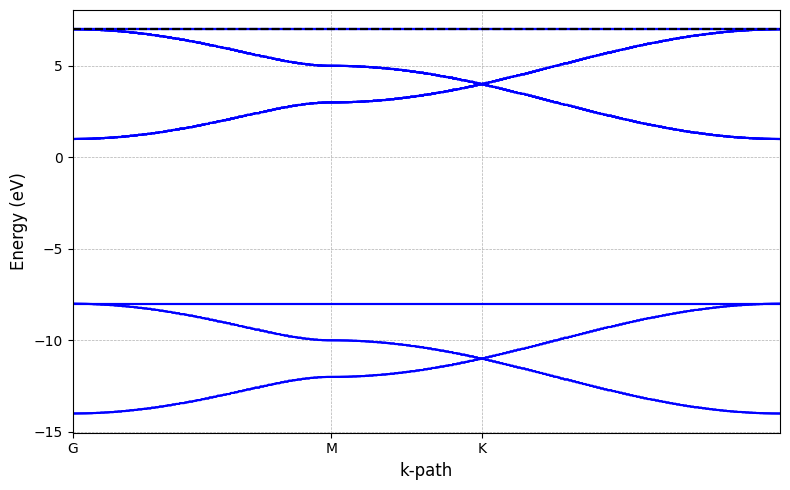

In [8]:
g = results[0].geometry
tb_bulk = results[0].hamiltonian[location]["tight_binding"]
invariants = results[0].hamiltonian[location]["topological_invariants"]

Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_acceptor_band_gap(only_dE=False)
print(dE)
tb_bulk.plot_band_structure(g, energies=[E_0, E_1])

## Case 1

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = 1.0
k=[ 1.57079633 -0.90689968]: delta = -1.0
k=[0.         1.81379936]: delta = 1.0
k=[1.57079633 0.90689968]: delta = 1.0
Z2 Invariant - Done!
Z2 Invariant: 1
-0.12541764235499286


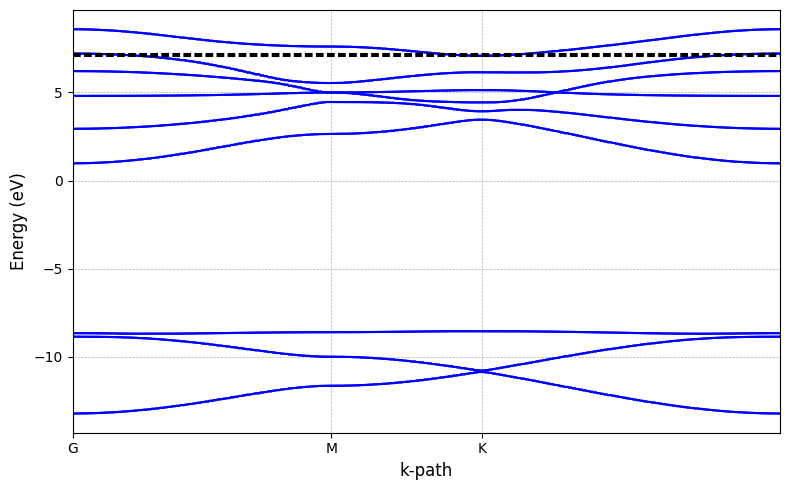

In [9]:
g = results[1].geometry
tb_bulk = results[1].hamiltonian[location]["tight_binding"]
invariants = results[1].hamiltonian[location]["topological_invariants"]
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_acceptor_band_gap(only_dE=False)
print(dE)
tb_bulk.plot_band_structure(g, energies=[E_0, E_1])

## Case 2

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = 1.0
k=[ 1.57079633 -0.90689968]: delta = -1.0
k=[0.         1.81379936]: delta = 1.0
k=[1.57079633 0.90689968]: delta = 1.0
Z2 Invariant - Done!
Z2 Invariant: 1
dE = -0.166 eV


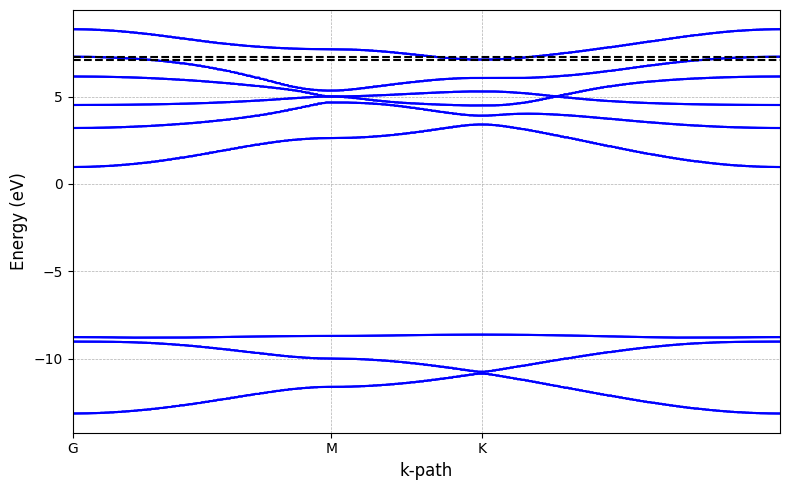

In [10]:
g = results[2].geometry
tb_bulk = results[2].hamiltonian[location]["tight_binding"]
invariants = results[2].hamiltonian[location]["topological_invariants"]
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_acceptor_band_gap(only_dE=False)
print(f"dE = {dE:.3f} eV")
tb_bulk.plot_band_structure(g, energies=[E_0, E_1])

## Case 3

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = 1.0
k=[ 1.57079633 -0.90689968]: delta = -1.0
k=[0.         1.81379936]: delta = -1.0
k=[1.57079633 0.90689968]: delta = 1.0
Z2 Invariant - Done!
Z2 Invariant: 0
dE = -0.252 eV


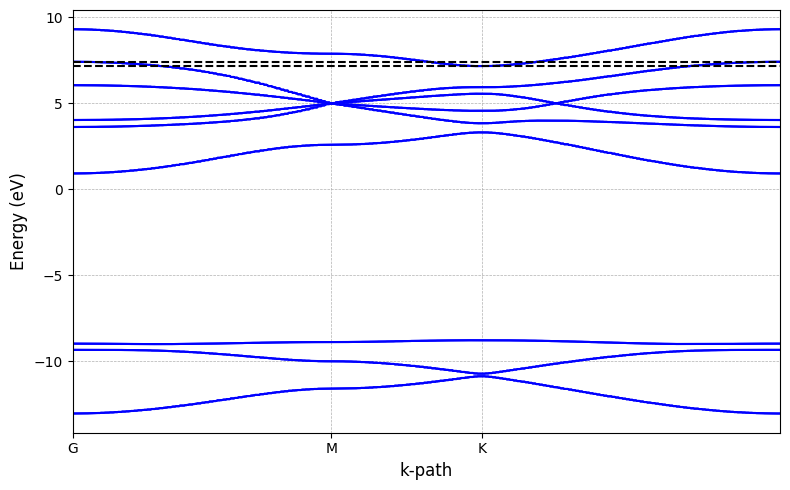

In [11]:
g = results[3].geometry
tb_bulk = results[3].hamiltonian[location]["tight_binding"]
invariants = results[3].hamiltonian[location]["topological_invariants"]
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_acceptor_band_gap(only_dE=False)
print(f"dE = {dE:.3f} eV")
tb_bulk.plot_band_structure(g, energies=[E_0, E_1])

## Case 4

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = -1.0
k=[ 1.57079633 -0.90689968]: delta = 1.0
k=[0.         1.81379936]: delta = -1.0
k=[1.57079633 0.90689968]: delta = -1.0
Z2 Invariant - Done!
Z2 Invariant: 1
dE = -0.484 eV


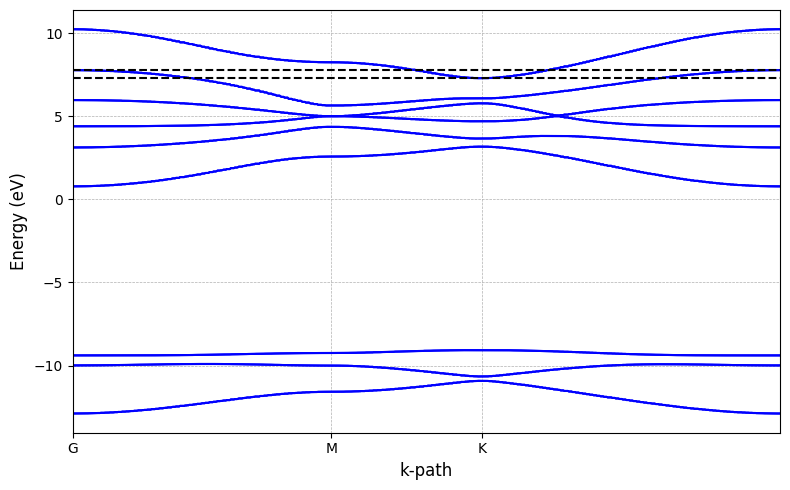

In [12]:
g = results[4].geometry
tb_bulk = results[4].hamiltonian[location]["tight_binding"]
invariants = results[4].hamiltonian[location]["topological_invariants"]
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_acceptor_band_gap(only_dE=False)
print(f"dE = {dE:.3f} eV")
tb_bulk.plot_band_structure(g, energies=[E_0, E_1])

In [13]:
Psi_k_0 = tb_bulk.band_structure_data["eigenvector_dict"][15]
Psi_k_0[0]

array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        6.15591915e-02+0.00000000e+00j,  1.28557787e-03-7.80368787e-04j,
       -1.66673941e-04-7.58694792e-03j, -4.82547045e-01-4.60846643e-16j,
        1.00773221e-02-6.11711498e-03j, -1.55316874e-01-2.69016718e-01j,
        5.55111512e-17+5.55111512e-17j,  3.33066907e-16+1.11022302e-16j,
       -3.07795957e-02-5.33118237e-02j,  3.30302586e-05+1.50352749e-03j,
       -6.48715267e-03+3.93781783e-03j,  2.41273523e-01+4.17898000e-01j,
        2.58915903e-04+1.17857745e-02j,  3.10633749e-01-7.63548863e-16j,
        1.08420217e-18-3.68628739e-18j,  0.00000000e+00+2.60208521e-18j,
       -3.07795957e-02+5.33118237e-02j, -1.31860813e-03-7.23158701e-04j,
        6.65382661e-03+3.64913009e-03j,  2.41273523e-01-4.17898000e-01j,
       -1.03362380e-02-5.66865948e-03j, -1.55316874e-01+2.69016718e-01j])

In [14]:
data = tb_bulk.sublattice_data_dict
idx_A, idx_B, idx_C = data["A"]["idx"], data["B"]["idx"], data["C"]["idx"]
r_A, r_B, r_C = g.sites[idx_A], g.sites[idx_B], g.sites[idx_C]

In [15]:
kx_bulk, ky_bulk = g.kx_bulk, g.ky_bulk
N_projections = len(tb_bulk.coupled_states)
slice_A = slice(0 * N_projections, (0 + 1) * N_projections)
slice_B = slice(1 * N_projections, (1 + 1) * N_projections)
slice_C = slice(2 * N_projections, (2 + 1) * N_projections)
Psi_r_0 = np.zeros(shape=Psi_k_0[0].shape, dtype=complex)
for k_idx, c_k_i in enumerate(Psi_k_0):
    k = np.array(tb_bulk.band_structure_data["k_bulk"][k_idx])
    # sublattice A
    phase_A = np.exp(-1j * np.dot(k, r_A))
    Psi_r_0[slice_A] += phase_A * c_k_i[slice_A]
    # sublattice B
    phase_B = np.exp(-1j * np.dot(k, r_B))
    Psi_r_0[slice_B] += phase_B * c_k_i[slice_B]
    # sublattice C
    phase_C = np.exp(-1j * np.dot(k, r_C))
    Psi_r_0[slice_C] += phase_C * c_k_i[slice_C]
N =  len(Psi_k_0)
Psi_r_0 /= np.sqrt(N)
Psi_r_0 /= np.sqrt(np.sum(np.abs(Psi_r_0)**2)) # enforce normalization

In [16]:
weight_A = np.sum(np.abs(Psi_r_0[slice_A])**2)
weight_B = np.sum(np.abs(Psi_r_0[slice_B])**2)
print("Weights A and B:", weight_A, weight_B)
print(np.sum(np.abs(Psi_r_0)**2))

Weights A and B: 0.3585965644400192 0.2774309454588597
1.0


In [17]:
I = np.identity(3)
M = tb_bulk.A.conj().T @ tb_bulk.C.conj().T
S = np.kron(I, M)
Psi_r = S @  Psi_r_0
print(np.sum(np.abs(Psi_r)**2))

0.9999999999999998


In [18]:
Psi_r

array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        3.31257281e-02+1.25059032e-01j, -1.24924004e-01-1.90432292e-01j,
       -1.12869780e-01-3.02447223e-02j,  1.03015176e-01+3.01351292e-01j,
       -2.18099662e-01+3.52633398e-01j,  5.45498805e-02-4.06214440e-03j,
        1.95570639e-16+9.91948007e-17j,  1.20225177e-16+6.11977315e-18j,
       -2.49758275e-02+5.05981098e-02j, -3.02758884e-02-2.02277500e-01j,
       -6.13989815e-02-4.74503319e-02j, -3.39467836e-01-1.59961910e-01j,
        2.29166331e-01-1.79090848e-01j,  3.09364558e-02-4.33264279e-03j,
        1.17337896e-17-4.31810331e-17j,  2.15809347e-17-4.88234561e-17j,
       -5.87221309e-02+6.03376624e-02j,  1.94392601e-01+3.53356444e-01j,
       -2.04225991e-02+3.99877344e-02j,  3.96003378e-02-1.09094842e-01j,
       -1.25540219e-01-3.80189382e-01j, -1.19490897e-01+6.45441504e-02j])